# Backpropagation Scartch Regression

# Import Libraries

In [ ]:
import random

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from sklearn.datasets import make_classification

In [ ]:
from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD
from keras.activations import sigmoid
from keras.losses import BinaryCrossentropy


# Make Dataset

In [ ]:
X, y = make_classification(n_samples=1000, n_classes=2, n_redundant=0, n_informative=2, n_features=2)
X.shape

(1000, 2)

# Plot Dataset

<Axes: >

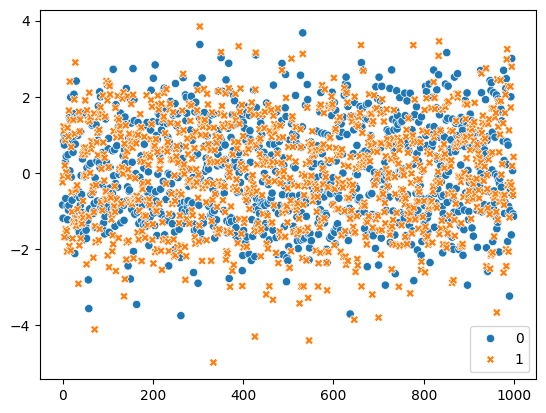

In [ ]:
sns.scatterplot(data=X)

# Custom Backpropagation

> Steps:
```
1. init weight, bias randomly
2. for i in epochs
  2.1 for row in X.row_num
    2.1.1 select a random row
    2.1.2 predict using forward propagation
    2.1.3 calculate loss
    2.1.4 update weights and biases
```

> Forword Propagation:

1. ̂y = O<sub>21</sub>\
    O<sub>21</sub> = O<sub>11</sub>W<sub>11</sub><sup>2</sup> + O<sub>21</sub>W<sub>12</sub><sup>2</sup> + b<sub>21</sub>

    O<sub>11</sub> = X<sub>1</sub>W<sub>11</sub><sup>1</sup> + X<sub>2</sub>W<sub>21</sub><sup>1</sup> + b<sub>11</sub>

    O<sub>12</sub> = X<sub>1</sub>W<sub>12</sub><sup>1</sup> + X<sub>2</sub>W<sub>22</sub><sup>1</sup> + b<sub>12</sub>


🧮 Backpropagation Parameter Update Equations

Given:  
- Learning rate: \( η \)  
- Input vector: \( X = [x_1, x_2] \)  
- Hidden layer outputs: \( O_{11}, O_{12} \)  
- Final output: \( \hat{y} \)  
- True label: \( y \)  

---

**1. Output Layer Gradient**

For the output neuron (sigmoid activation + binary cross-entropy loss):

\[
  \frac{\partial L}{\partial Z_{21}} = \hat{y} - y
\]

---

**2. Hidden Layer Gradients**

Backpropagate the error from the output layer to the hidden layer neurons:

\[
\begin{aligned}
\frac{\partial L}{\partial O_{11}} &= w_4 \cdot (\hat{y} - y) \\
\frac{\partial L}{\partial O_{12}} &= w_5 \cdot (\hat{y} - y)
\end{aligned}
\]

Including the sigmoid derivative \( O(1 - O) \):

\[
\begin{aligned}
dO_{11} &= w_4 \cdot O_{11} (1 - O_{11}) \cdot (\hat{y} - y) \\
dO_{12} &= w_5 \cdot O_{12} (1 - O_{12}) \cdot (\hat{y} - y)
\end{aligned}
\]

---

**3. Weight and Bias Updates**

**Output layer:**

\[
\begin{aligned}
w_4 &\leftarrow w_4 - \eta \cdot (\hat{y} - y) \cdot O_{11} \\
w_5 &\leftarrow w_5 - \eta \cdot (\hat{y} - y) \cdot O_{12} \\
b_3 &\leftarrow b_3 - \eta \cdot (\hat{y} - y)
\end{aligned}
\]

**Hidden layer:**

\[
\begin{aligned}
w_0 &\leftarrow w_0 - \eta \cdot dO_{11} \cdot x_1 \\
w_2 &\leftarrow w_2 - \eta \cdot dO_{11} \cdot x_2 \\
b_1 &\leftarrow b_1 - \eta \cdot dO_{11} \\
\\
w_1 &\leftarrow w_1 - \eta \cdot dO_{12} \cdot x_1 \\
w_3 &\leftarrow w_3 - \eta \cdot dO_{12} \cdot x_2 \\
b_2 &\leftarrow b_2 - \eta \cdot dO_{12}
\end{aligned}
\]

---

**Summary Table**

| Layer  | Parameter(s) | Update Rule |
|:--------|:--------------|:-------------|
| Output  | \( w_4, w_5 \) | \( w_i \leftarrow w_i - \eta (\hat{y} - y) O_{1i} \) |
| Output  | \( b_3 \) | \( b_3 \leftarrow b_3 - \eta (\hat{y} - y) \) |
| Hidden  | \( w_0, w_2, b_1 \) | \( w, b \leftarrow w, b - \eta \, dO_{11} \, [x_1, x_2, 1] \) |
| Hidden  | \( w_1, w_3, b_2 \) | \( w, b \leftarrow w, b - \eta \, dO_{12} \, [x_1, x_2, 1] \) |


In [ ]:
class MyBackpropagationNNClassifier:
  def __init__(self, lr=0.01, epochs=5) -> None:
    self.lr = lr
    self.epochs = epochs
    self.weights_ = []
    self.bias_ = []
    self.loss_calculate = []
    self.epochs_loss = []
    self._init_weights = []
    self._init_bias = []


  def sigmoid(self, x)-> float:
    return 1 / (1+np.exp(-x))


  def forward_propagation(self, X, y):

    # Hidden Layer
    Z11 = self.weights_[0]*X[0] + self.weights_[2]*X[1] + self.bias_[0]
    Z12 = self.weights_[1]*X[0] + self.weights_[3]*X[1] + self.bias_[1]

    # Output Layer
    Z21 = self.weights_[4]*Z11 + self.weights_[5]*Z12 + self.bias_[2]

    return self.sigmoid(Z11), self.sigmoid(Z12), self.sigmoid(Z21)


  def update_parameters(self, X, y, y_hat, O11, O12):
    dL_dYhat_dZ = y_hat-y

    # Gradients for hidden neurons
    dO11 = self.weights_[4] * O11 * (1 - O11) * dL_dYhat_dZ
    dO12 = self.weights_[5] * O12 * (1 - O12) * dL_dYhat_dZ

    # Output layer updates
    self.weights_[4] -= self.lr * dL_dYhat_dZ * O11
    self.weights_[5] -= self.lr * dL_dYhat_dZ * O12
    self.bias_[2] -= self.lr * dL_dYhat_dZ

    # Hidden layer updates
    self.weights_[0] -= self.lr * dO11 * X[0]
    self.weights_[2] -= self.lr * dO11 * X[1]
    self.bias_[0] -= self.lr * dO11

    self.weights_[1] -= self.lr * dO12 * X[0]
    self.weights_[3] -= self.lr * dO12 * X[1]
    self.bias_[1] -= self.lr * dO12


  def fit(self, X, y):
    # self.weights_ = np.array([random.random() for _ in range(6)])
    # self.bias_ = np.array([random.random() for _ in range(3)])

    self.weights_ = np.random.uniform(-1, 1, 6)
    self.bias_ = np.random.uniform(-1, 1, 3)


    self._init_weights = self.weights_.copy()
    self._init_bias = self.bias_.copy()

    for _ in range(self.epochs):
      for _i in range(X.shape[0]):

        index = random.randint(0, X.shape[0]-1)

        O11, O12, O21 = self.forward_propagation(X[index], y[index])
        O12 = np.clip(O12, 1e-10, 1-1e-10)
        O11 = np.clip(O11, 1e-10, 1-1e-10)
        O21 = np.clip(O21, 1e-10, 1-1e-10)

        binary_loss = -y[index]*np.log(O21) - (1-y[index])*np.log(1-O21)
        self.loss_calculate.append(binary_loss)

        # Update Parameter
        self.update_parameters(X=X[index], y=y[index], y_hat=O21, O11=O11, O12=O12)

      self.epochs_loss.append(np.mean(self.loss_calculate))
      print(f'epochs {_}/{self.epochs}, loss={self.epochs_loss[_]:.4f}')

      self.loss_calculate.clear()


  def get_weights(self, type: str = 'updated'):
      # Select which set of weights to return
      if type == 'init':
          w = self._init_weights
          b = self._init_bias
      else:
          w = self.weights_
          b = self.bias_

      # Map to Keras format
      return [
          np.array([[w[0], w[1]],      # dense_4 kernel (2x2)
                    [w[2], w[3]]]),
          np.array([b[0], b[1]]),      # dense_4 bias (2,)
          np.array([[w[4]],            # dense_5 kernel (2x1)
                    [w[5]]]),
          np.array([b[2]])             # dense_5 bias (1,)
      ]

In [ ]:
my_model = MyBackpropagationNNClassifier(lr=0.01, epochs=10)
my_model.fit(X, y)

epochs 0/10, loss=0.7102
epochs 1/10, loss=0.3733
epochs 2/10, loss=0.2717
epochs 3/10, loss=0.2652
epochs 4/10, loss=0.2264
epochs 5/10, loss=0.2498
epochs 6/10, loss=0.2730
epochs 7/10, loss=0.2447
epochs 8/10, loss=0.2406
epochs 9/10, loss=0.2480


In [ ]:
my_model.get_weights(type='init')

[array([[ 0.1811299 , -0.93814716],
        [ 0.28161626,  0.90704537]]),
 array([ 0.91553457, -0.32877421]),
 array([[-0.89153316],
        [ 0.74718881]]),
 array([0.76673164])]

# Keras Model

In [ ]:
keras_model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(units=2, activation=sigmoid),
    Dense(units=1, activation=sigmoid)
])

In [ ]:
keras_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

## Set weights and bias

In [ ]:
keras_model.get_weights()

[array([[ 0.4081545 , -1.1804858 ],
        [-1.0199587 ,  0.26941824]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.6150571],
        [-1.2315114]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
new_weight = [
    np.array([my_model._init_weights[0:2].tolist(), my_model._init_weights[2:4].tolist()]),
    np.array(my_model._init_bias[:2].tolist()),
    np.array([[my_model._init_weights[4].tolist()], [my_model._init_weights[5].tolist()]]),
    np.array([my_model._init_bias[2].tolist()])
]
keras_model.set_weights(new_weight)
keras_model.get_weights()

[array([[ 0.1811299 , -0.9381471 ],
        [ 0.28161627,  0.90704536]], dtype=float32),
 array([ 0.91553456, -0.3287742 ], dtype=float32),
 array([[-0.89153314],
        [ 0.7471888 ]], dtype=float32),
 array([0.7667316], dtype=float32)]

In [ ]:
keras_model.compile(
  optimizer=SGD(learning_rate=0.01),
  loss = BinaryCrossentropy(),
  metrics=['accuracy']
)

In [ ]:
keras_model.fit(X, y, batch_size=1, epochs=10)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4836 - loss: 0.7386
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8679 - loss: 0.5735
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8896 - loss: 0.4579
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8968 - loss: 0.3903
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9094 - loss: 0.3369
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9119 - loss: 0.3004
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9062 - loss: 0.3010
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9071 - loss: 0.2841
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8999 - loss: 0.2832
Epoch 10/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9030 - loss: 0.2784


# Compare custom class vs keras class weights

In [ ]:
my_model.get_weights()

[array([[-1.69065027, -0.66092386],
        [ 0.31673332,  0.99737427]]),
 array([ 0.49954928, -0.39731432]),
 array([[-1.85485808],
        [-0.25641129]]),
 array([1.07847055])]

In [ ]:
keras_model.get_weights()

[array([[-3.0625417 , -1.8199387 ],
        [ 0.6986567 ,  0.65424037]], dtype=float32),
 array([-0.16237557, -0.47920048], dtype=float32),
 array([[-4.195196 ],
        [-1.6672896]], dtype=float32),
 array([2.820514], dtype=float32)]